In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def rotasi_bebas_crop(image, derajat):
    h, w = image.shape
    sudut = np.radians(derajat)

    cx, cy = w / 2, h / 2

    hasil = np.zeros((h, w), dtype=image.dtype)

    for i in range(h):
        for j in range(w):
            x = (j - cx) * np.cos(-sudut) - (i - cy) * np.sin(-sudut) + cx
            y = (j - cx) * np.sin(-sudut) + (i - cy) * np.cos(-sudut) + cy

            x, y = int(round(x)), int(round(y))

            if 0 <= x < w and 0 <= y < h:
                hasil[i, j] = image[y, x]

    return hasil

def thresholdTio(image, angkaThresholding):
    h, w = image.shape
    thresholding = np.zeros((w, h), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if image[i, j] >= angkaThresholding:
                thresholding[i, j] = 255
            else:
                thresholding[i, j] = 0
    return thresholding

def clipping(citra):
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            val = citra[i,j]
            hasil[i,j] = 255 if val > 255 else (0 if val < 0 else int(val))
    return hasil

def zero_padding(citra, pad):
    h, w = citra.shape
    hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    hasil[pad:pad+h, pad:pad+w] = citra
    return hasil

def rotasi_bebas(image, derajat):
    h, w = image.shape
    sudut = np.radians(derajat)
    cos_a = abs(np.cos(sudut))
    sin_a = abs(np.sin(sudut))
    new_w = int(w * cos_a + h * sin_a)
    new_h = int(w * sin_a + h * cos_a)
    cx_lama, cy_lama = w / 2, h / 2
    cx_baru, cy_baru = new_w / 2, new_h / 2
    hasil = np.zeros((new_h, new_w), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            x = (j - cx_baru) * np.cos(-sudut) - (i - cy_baru) * np.sin(-sudut) + cx_lama
            y = (j - cx_baru) * np.sin(-sudut) + (i - cy_baru) * np.cos(-sudut) + cy_lama
            x, y = int(round(x)), int(round(y))
            if 0 <= x < w and 0 <= y < h:
                hasil[i, j] = image[y, x]
    return hasil


def gabung_tumpuk(citra_1, citra_2):
    return citra_1 + citra_2

def tumpuk_citra(citra_1, citra_2):
    h, w = citra_1.shape
    hasil = np.zeros((h, w), dtype=np.int32)
    
    for i in range(h):
        for j in range(w):
                if citra_2[i, j] > 0:
                    hasil[i, j] = citra_2[i, j]
                else:
                    hasil[i, j] = citra_1[i, j]
    return hasil

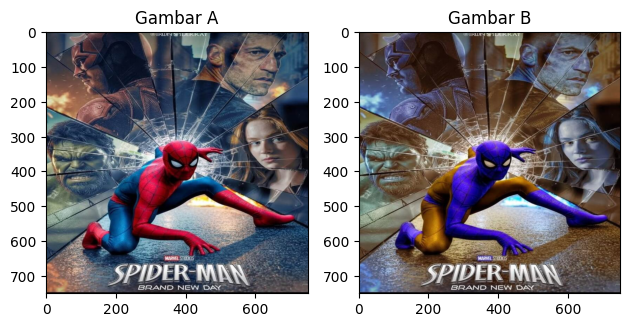

In [3]:

gambarA = plt.imread('brandnewday.jpg') 
gambarB = cv.imread('brandnewday.jpg')   

plt.subplot(1, 2, 1)
plt.imshow(gambarA)
plt.title('Gambar A')

plt.subplot(1, 2, 2)
plt.imshow(gambarB)
plt.title('Gambar B')

plt.tight_layout()
plt.show()

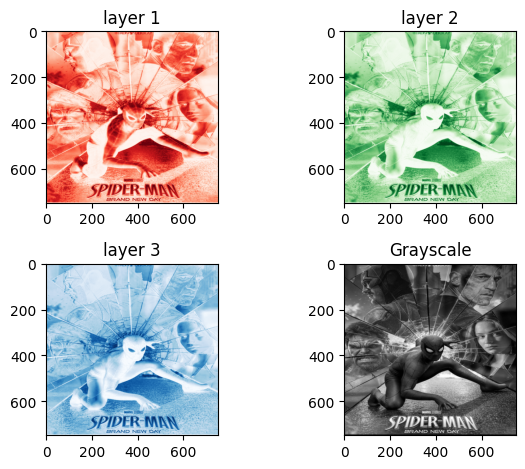

In [4]:
A_1   = gambarA[:, :, 0]
A_2 = gambarA[:, :, 1]
A_3  = gambarA[:, :, 2]

A_Gray = cv.cvtColor(gambarA, cv.COLOR_RGB2GRAY)

plt.subplot(2, 2, 1)
plt.imshow(A_1, cmap='Reds')
plt.title('layer 1')

plt.subplot(2, 2, 2)
plt.imshow(A_2, cmap='Greens')
plt.title('layer 2')

plt.subplot(2, 2, 3)
plt.imshow(A_3, cmap='Blues')
plt.title('layer 3')

plt.subplot(2, 2, 4)
plt.imshow(A_Gray, cmap='gray')
plt.title('Grayscale')

plt.tight_layout()
plt.show()

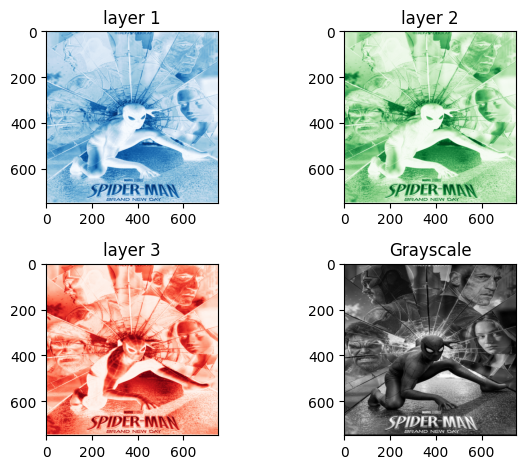

In [5]:
B_1 = gambarB[:, :, 0]  
B_2 = gambarB[:, :, 1]  
B_3 = gambarB[:, :, 2]  

B_gray = cv.cvtColor(gambarB, cv.COLOR_BGR2GRAY)

plt.subplot(2, 2, 1)
plt.imshow(B_1, cmap='Blues')
plt.title('layer 1')  

plt.subplot(2, 2, 2)
plt.imshow(B_2, cmap='Greens')  
plt.title('layer 2')  

plt.subplot(2, 2, 3)
plt.imshow(B_3, cmap='Reds')
plt.title('layer 3')      

plt.subplot(2, 2, 4)
plt.imshow(B_gray, cmap='gray')
plt.title('Grayscale')

plt.tight_layout()
plt.show()

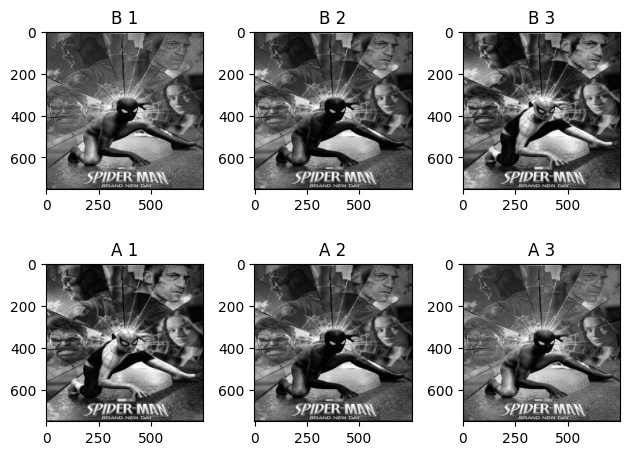

In [6]:
plt.subplot(2, 3, 1)
plt.imshow(B_1, cmap = 'gray')
plt.title("B 1")
plt.subplot(2, 3, 2)
plt.imshow(B_2, cmap = 'gray')
plt.title("B 2")
plt.subplot(2, 3, 3)
plt.imshow(B_3, cmap = 'gray')
plt.title("B 3")
plt.subplot(2, 3, 4)
plt.imshow(A_1, cmap = 'gray')
plt.title("A 1")
plt.subplot(2, 3, 5)
plt.imshow(A_2, cmap = 'gray')
plt.title("A 2")
plt.subplot(2, 3, 6)
plt.imshow(A_3, cmap = 'gray')
plt.title("A 3")

plt.tight_layout()
plt.show()

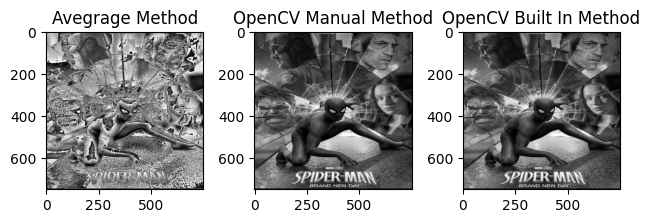

In [7]:
B_Avegrage_Method = (B_1 + B_2 + B_3) / 3

B_OpenCV_Manual_Method = 0.299 * B_3 + 0.587 * B_2 + 0.114 * B_1

plt.subplot(1, 3, 1)
plt.imshow(B_Avegrage_Method, cmap='gray')
plt.title('Avegrage Method')
plt.subplot(1, 3, 2)
plt.imshow(B_OpenCV_Manual_Method, cmap='gray')
plt.title('OpenCV Manual Method')

plt.subplot(1, 3, 3)
plt.imshow(B_gray, cmap='gray')
plt.title('OpenCV Built In Method')

plt.tight_layout()
plt.show()

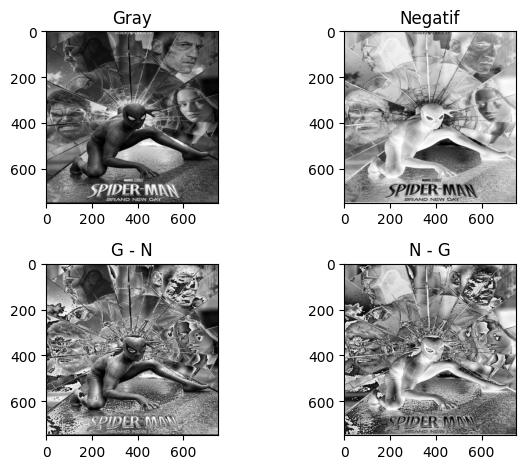

In [8]:
B_negatif = 255 - B_gray

B_gray_kurang_negatifGray = B_gray - B_negatif
clipping(B_gray_kurang_negatifGray)

B_negatifGray_kurang_gray = B_negatif - B_gray
clipping(B_negatifGray_kurang_gray)

plt.subplot(2,2,1)
plt.imshow(B_gray, cmap='gray')
plt.title('Gray')
plt.subplot(2,2,2)
plt.imshow(B_negatif, cmap='gray')
plt.title('Negatif')
plt.subplot(2,2,3)
plt.imshow(B_gray_kurang_negatifGray, cmap='gray')
plt.title('G - N')
plt.subplot(2,2,4)
plt.imshow(B_negatifGray_kurang_gray, cmap='gray')
plt.title('N - G')

plt.tight_layout()
plt.show()

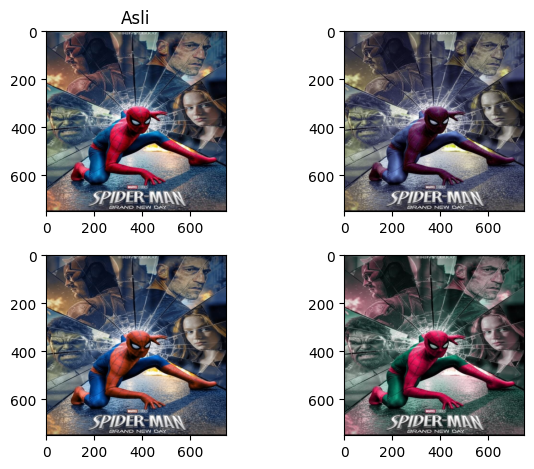

In [9]:
A_diganti_Red = gambarA.copy()
A_diganti_Green = gambarA.copy()
A_diganti_Blue = gambarA.copy()

A_diganti_Red[:, :, 0] = A_Gray  
A_diganti_Green[:, :, 1] = A_Gray  
A_diganti_Blue[:, :, 2] = A_Gray  

plt.subplot(2, 2, 1)
plt.imshow(gambarA)
plt.title('Asli')

plt.subplot(2, 2, 2)
plt.imshow(A_diganti_Red)

plt.subplot(2, 2, 3)
plt.imshow(A_diganti_Green)

plt.subplot(2, 2, 4)
plt.imshow(A_diganti_Blue)

plt.tight_layout()
plt.show()

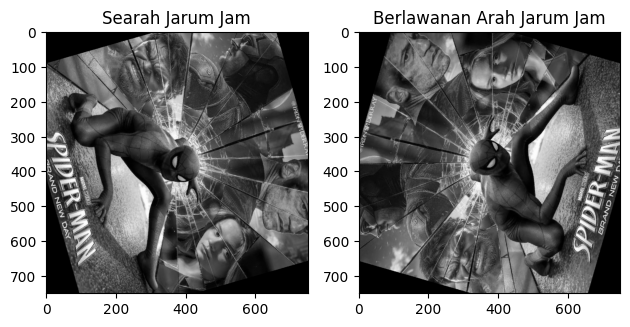

In [10]:
rotasiSearah_B = rotasi_bebas_crop(B_gray, 74)
rotasiBerlawananArah_B = rotasi_bebas_crop(B_gray, -74)

plt.subplot(1,2,1)
plt.imshow(rotasiSearah_B, cmap='gray')
plt.title('Searah Jarum Jam')
plt.subplot(1,2,2)
plt.imshow(rotasiBerlawananArah_B, cmap='gray')
plt.title('Berlawanan Arah Jarum Jam')

plt.tight_layout()
plt.show()

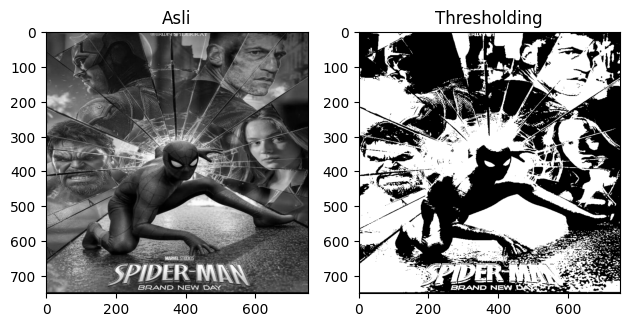

In [11]:
B_thresholding = thresholdTio(B_gray, 74)

plt.subplot(1,2,1)
plt.imshow(B_gray, cmap='gray')
plt.title('Asli')
plt.subplot(1,2,2)
plt.imshow(B_thresholding, cmap='gray')
plt.title('Thresholding')

plt.tight_layout()
plt.show()

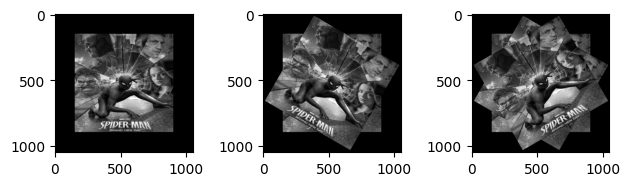

In [12]:
B_gray_zeroPadding  = zero_padding(B_gray, 150)

B_gray_30drjt       = rotasi_bebas_crop(B_gray_zeroPadding, 30)
B_gray_neg_30drjt   = rotasi_bebas_crop(B_gray_zeroPadding, -30)

B_tumpuk1 = tumpuk_citra(B_gray_zeroPadding, B_gray_30drjt)
B_tumpuk2 = tumpuk_citra(B_tumpuk1, B_gray_neg_30drjt)

plt.subplot(1, 3, 1)
plt.imshow(B_gray_zeroPadding, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(B_tumpuk1, cmap='gray')

plt.subplot(1, 3, 3)
plt.imshow(B_tumpuk2, cmap='gray')

plt.tight_layout()
plt.show()

In [13]:
# TOLONGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG